# Adaptive MLP for CKD Detection

This notebook trains an adaptive Multi-Layer Perceptron on the processed CKD dataset.

## Objectives

- Load the pre-split, leakage-free train/test CKD data (output of `preprocessing.ipynb`)
- Scale features using statistics fit on the training set only
- Train an MLP incrementally on growing batches of training data
- Adapt network capacity (hidden layer size) when F1 score stops improving
- Evaluate the best adaptive model and save results/figures

Output:

- `results/week6/ckd_adaptive_mlp_result.csv`
- `results/week6/ckd_adaptive_mlp_confusion_matrix.png`

In [13]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Only silence the specific noisy warning we've inspected and accepted
# (MLPClassifier occasionally not fully converging within max_iter on
# small batches) rather than suppressing every warning class.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

os.makedirs("../../results/week6", exist_ok=True)

## Load Pre-Split Data

In [14]:
# preprocessing.ipynb now splits BEFORE imputing/encoding, so these two
# files are already leakage-free — no re-splitting here, and no imputer
# or encoder in this notebook ever sees the test set.

train_df = pd.read_csv("../../data/processed/chronic_kidney_disease_train.csv")
test_df = pd.read_csv("../../data/processed/chronic_kidney_disease_test.csv")

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

X_train = train_df.drop("class", axis=1)
y_train = train_df["class"].reset_index(drop=True)

X_test = test_df.drop("class", axis=1)
y_test = test_df["class"].reset_index(drop=True)

print("\nTrain class balance:")
print(y_train.value_counts())
print("\nTest class balance:")
print(y_test.value_counts())

Train shape: (320, 25)
Test shape : (80, 25)

Train class balance:
class
1    200
0    120
Name: count, dtype: int64

Test class balance:
class
1    50
0    30
Name: count, dtype: int64


## Scaling

Fit on the training set only, then applied to test — consistent with how the split itself
was handled upstream in `preprocessing.ipynb`.

In [15]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Adaptive Training

The model starts with 64 hidden neurons and trains on growing batches of the training set
(64 samples at a time). Whenever a batch fails to improve F1 over the current best, the
hidden layer grows by 32 neurons for the next batch — this is the "adaptive" behaviour.

In [16]:
batch_size = 64
hidden_layer = (64,)

best_f1 = 0
best_model = None

results = []

for end in range(batch_size, len(X_train) + 1, batch_size):

    X_batch = X_train[:end]
    y_batch = y_train[:end]

    model = MLPClassifier(
        hidden_layer_sizes=hidden_layer,
        activation="relu",
        solver="adam",
        max_iter=1000,
        random_state=42
    )

    model.fit(X_batch, y_batch)

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)
    roc = roc_auc_score(y_test, prob)

    results.append([end, hidden_layer[0], acc, prec, rec, f1, roc])

    print("=" * 60)
    print(f"Training Samples : {end}")
    print(f"Hidden Neurons    : {hidden_layer[0]}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC AUC   : {roc:.4f}")

    # ------------------------
    # Adaptation
    # ------------------------

    if f1 > best_f1:
        best_f1 = f1
        best_model = model
    else:
        hidden_layer = (hidden_layer[0] + 32,)
        print("Adaptive Update")
        print("Increasing hidden neurons to", hidden_layer[0])

Training Samples : 64
Hidden Neurons    : 64
Accuracy  : 0.9750
Precision : 1.0000
Recall    : 0.9600
F1 Score  : 0.9796
ROC AUC   : 0.9993
Training Samples : 128
Hidden Neurons    : 64
Accuracy  : 0.9750
Precision : 1.0000
Recall    : 0.9600
F1 Score  : 0.9796
ROC AUC   : 0.9973
Adaptive Update
Increasing hidden neurons to 96
Training Samples : 192
Hidden Neurons    : 96
Accuracy  : 0.9750
Precision : 1.0000
Recall    : 0.9600
F1 Score  : 0.9796
ROC AUC   : 0.9980
Adaptive Update
Increasing hidden neurons to 128
Training Samples : 256
Hidden Neurons    : 128
Accuracy  : 0.9875
Precision : 1.0000
Recall    : 0.9800
F1 Score  : 0.9899
ROC AUC   : 1.0000
Training Samples : 320
Hidden Neurons    : 128
Accuracy  : 0.9875
Precision : 1.0000
Recall    : 0.9800
F1 Score  : 0.9899
ROC AUC   : 0.9993
Adaptive Update
Increasing hidden neurons to 160


### Final batch

If the training set size isn't an exact multiple of `batch_size`, the remaining samples
are never used above — this final step trains once more on the **full** training set at
the last adapted hidden-layer size, so no data is left out of training.

In [17]:
if len(X_train) % batch_size != 0:

    model = MLPClassifier(
        hidden_layer_sizes=hidden_layer,
        activation="relu",
        solver="adam",
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    f1 = f1_score(y_test, pred, zero_division=0)

    if f1 > best_f1:
        best_f1 = f1
        best_model = model
        print("Final full-batch model is the new best (F1 =", round(f1, 4), ")")

## Final Evaluation

In [18]:
print("=" * 60)
print("BEST ADAPTIVE MODEL")
print("=" * 60)

pred = best_model.predict(X_test)
prob = best_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred, zero_division=0)
recall = recall_score(y_test, pred, zero_division=0)
f1 = f1_score(y_test, pred, zero_division=0)
auc = roc_auc_score(y_test, prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC AUC  :", auc)

BEST ADAPTIVE MODEL
Accuracy : 0.9875
Precision: 1.0
Recall   : 0.98
F1 Score : 0.98989898989899
ROC AUC  : 1.0


## Error Analysis

In [19]:
analysis = pd.DataFrame({
    "Actual": y_test,
    "Predicted": pred
})

false_negatives = analysis[
    (analysis["Actual"] == 1) &
    (analysis["Predicted"] == 0)
]

false_positives = analysis[
    (analysis["Actual"] == 0) &
    (analysis["Predicted"] == 1)
]

print("False Negatives")
print(false_negatives)
print("\nTotal False Negatives:", len(false_negatives))

print("\nFalse Positives")
print(false_positives)
print("\nTotal False Positives:", len(false_positives))

False Negatives
   Actual  Predicted
9       1          0

Total False Negatives: 1

False Positives
Empty DataFrame
Columns: [Actual, Predicted]
Index: []

Total False Positives: 0


## Save Results

In [20]:
adaptive_results = pd.DataFrame({
    "Model": ["Adaptive MLP"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1": [f1],
    "AUC": [auc]
})

adaptive_results.to_csv(
    "../../results/week6/ckd_adaptive_mlp_result.csv",
    index=False
)

print("Saved results/week6/ckd_adaptive_mlp_result.csv")

adaptive_results

Saved results/week6/ckd_adaptive_mlp_result.csv


,Model,Accuracy,Precision,Recall,F1,AUC
0,Adaptive MLP,0.9875,1.0,0.98,0.989899,1.0


## Confusion Matrix Figure

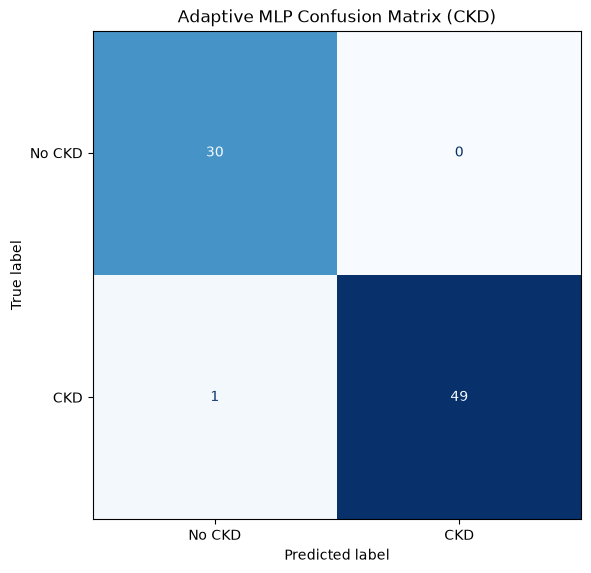

Confusion matrix saved to results/week6/ckd_adaptive_mlp_confusion_matrix.png


In [21]:
cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No CKD", "CKD"]
)

fig, ax = plt.subplots(figsize=(6, 6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Adaptive MLP Confusion Matrix (CKD)")
plt.tight_layout()

plt.savefig(
    "../../results/week6/ckd_adaptive_mlp_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved to results/week6/ckd_adaptive_mlp_confusion_matrix.png")

## Batch-by-Batch Progression

In [22]:
progress = pd.DataFrame(
    results,
    columns=["Training Samples", "Hidden Neurons", "Accuracy", "Precision", "Recall", "F1", "ROC AUC"]
)

progress

,Training Samples,Hidden Neurons,Accuracy,Precision,Recall,F1,ROC AUC
0,64,64,0.9750,1.0,0.96,0.979592,0.999333
1,128,64,0.9750,1.0,0.96,0.979592,0.997333
2,192,96,0.9750,1.0,0.96,0.979592,0.998000
3,256,128,0.9875,1.0,0.98,0.989899,1.000000
4,320,128,0.9875,1.0,0.98,0.989899,0.999333


In [23]:
print("=" * 50)
print("Adaptive MLP training completed successfully")
print("=" * 50)

Adaptive MLP training completed successfully
